In [19]:
# Data Preparation
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. set parameters
BATCH_SIZE = 64
IMG_SIZE = 224
NUM_CLASSES = 11       # Food-11
LEARNING_RATE = 0.001
EPOCHS = 10
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. data trasforms
# Data Augmentation
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

strong_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),        # horizon flip
    transforms.RandomRotation(15),            # random retation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # normalize
])

# validation dataset and evaluation dataset preprocess trasfer to Tensor
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. import dataset
train_path = '/content/food11_dataset/training'
val_path   = '/content/food11_dataset/validation'
test_path  = '/content/food11_dataset/evaluation'

train_set_basic = ImageFolder(f'{train_path}', transform=basic_transform)
train_loader_basic = DataLoader(train_set_basic, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

train_set_strong = ImageFolder(f'{train_path}', transform=strong_transform)
train_loader_strong = DataLoader(train_set_strong, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

val_set = ImageFolder(f'{val_path}', transform=test_transform)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

test_set = ImageFolder(f'{test_path}', transform=test_transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"training set: {len(train_set_basic)} | validation set: {len(val_set)} | testing set: {len(test_set)}")

training set: 9866 | validation set: 3430 | testing set: 3347


In [20]:
# --- Phase 1: Basic CNN (Only Conv + FC, No Pooling) ---
class Phase1_Net(nn.Module):
    def __init__(self, num_classes=11):
        super(Phase1_Net, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.classifier = nn.Linear(128 * 28 * 28, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# --- Phase 2: Add Pooling (Conv + Pooling) ---
class Phase2_Net(nn.Module):
    def __init__(self, num_classes=11):
        super(Phase2_Net, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2), # Pooling
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2), # Pooling
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Pooling
        )
        self.classifier = nn.Linear(128 * 28 * 28, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# --- Phase 3: Add Dropout (Addressing Overfitting) ---
class Phase3_Net(nn.Module):
    def __init__(self, num_classes=11):
        super(Phase3_Net, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),  # Dropout
            nn.Linear(128 * 28 * 28, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [25]:
# training phase 1~3
def train_model(model, name, loader, epochs=10):
    print(f"\n🚀 training: {name} ...")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        history.append(acc)
        print(f"[{name}] Epoch {epoch+1}: Acc = {acc:.2f}%")

    return history

model_phase1 = Phase1_Net()
model_phase2 = Phase2_Net()
model_phase3 = Phase3_Net()

acc_p1 = train_model(model_phase1, "Phase 1 (Basic)", train_loader_basic)
acc_p2 = train_model(model_phase2, "Phase 2 (+Pooling)", train_loader_basic)
acc_p3 = train_model(model_phase3, "Phase 3 (+Dropout)", train_loader_basic)


🚀 training: Phase 1 (Basic) ...
[Phase 1 (Basic)] Epoch 1: Acc = 27.90%
[Phase 1 (Basic)] Epoch 2: Acc = 40.88%
[Phase 1 (Basic)] Epoch 3: Acc = 53.66%
[Phase 1 (Basic)] Epoch 4: Acc = 72.71%
[Phase 1 (Basic)] Epoch 5: Acc = 90.50%
[Phase 1 (Basic)] Epoch 6: Acc = 97.30%
[Phase 1 (Basic)] Epoch 7: Acc = 98.84%
[Phase 1 (Basic)] Epoch 8: Acc = 99.69%
[Phase 1 (Basic)] Epoch 9: Acc = 99.83%
[Phase 1 (Basic)] Epoch 10: Acc = 99.94%

🚀 training: Phase 2 (+Pooling) ...
[Phase 2 (+Pooling)] Epoch 1: Acc = 26.24%
[Phase 2 (+Pooling)] Epoch 2: Acc = 37.72%
[Phase 2 (+Pooling)] Epoch 3: Acc = 43.93%
[Phase 2 (+Pooling)] Epoch 4: Acc = 51.82%
[Phase 2 (+Pooling)] Epoch 5: Acc = 60.84%
[Phase 2 (+Pooling)] Epoch 6: Acc = 70.63%
[Phase 2 (+Pooling)] Epoch 7: Acc = 81.31%
[Phase 2 (+Pooling)] Epoch 8: Acc = 91.29%
[Phase 2 (+Pooling)] Epoch 9: Acc = 96.36%
[Phase 2 (+Pooling)] Epoch 10: Acc = 98.25%

🚀 training: Phase 3 (+Dropout) ...
[Phase 3 (+Dropout)] Epoch 1: Acc = 25.64%
[Phase 3 (+Dropout)]

In [22]:
# --- Phase 4: ShuffleNet Transfer Learning ---
print("\n🚀 training Phase 4: ShuffleNet V2 (Frozen + MLP)...")

# load model
model_shufflenet = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.DEFAULT)

# Freeze
for param in model_shufflenet.parameters():
    param.requires_grad = False

# Input: 1024 -> Linear -> ReLU -> Dropout -> Linear -> Output: 11
model_shufflenet.fc = nn.Sequential(
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 11)
)

model_shufflenet = model_shufflenet.to(device)

# optimize
optimizer = optim.Adam(model_shufflenet.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# train
shuffle_train_acc = []
shuffle_val_acc = []
shuffle_loss = []

EPOCHS_SHUFFLE = 20

for epoch in range(EPOCHS_SHUFFLE):
    # Train
    model_shufflenet.train()
    correct = 0
    total = 0
    run_loss = 0.0

    # use Strong Augmentation 的 Loader
    for images, labels in train_loader_strong:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_shufflenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        run_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    avg_loss = run_loss / len(train_loader_strong)
    shuffle_train_acc.append(train_acc)
    shuffle_loss.append(avg_loss)

    # Validation
    model_shufflenet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_shufflenet(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    shuffle_val_acc.append(val_acc)

    print(f"[ShuffleNet] Epoch {epoch+1}/{EPOCHS_SHUFFLE} | Loss: {avg_loss:.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

print("✅ end Phase 4")


🚀 training Phase 4: ShuffleNet V2 (Frozen + MLP)...
[ShuffleNet] Epoch 1/20 | Loss: 1.8760 | Train: 39.98% | Val: 60.82%
[ShuffleNet] Epoch 2/20 | Loss: 1.1711 | Train: 63.67% | Val: 70.55%
[ShuffleNet] Epoch 3/20 | Loss: 0.9458 | Train: 69.95% | Val: 74.99%
[ShuffleNet] Epoch 4/20 | Loss: 0.8474 | Train: 73.03% | Val: 76.85%
[ShuffleNet] Epoch 5/20 | Loss: 0.7829 | Train: 74.64% | Val: 78.05%
[ShuffleNet] Epoch 6/20 | Loss: 0.7319 | Train: 75.72% | Val: 77.78%
[ShuffleNet] Epoch 7/20 | Loss: 0.7045 | Train: 76.69% | Val: 79.59%
[ShuffleNet] Epoch 8/20 | Loss: 0.6705 | Train: 78.38% | Val: 79.10%
[ShuffleNet] Epoch 9/20 | Loss: 0.6461 | Train: 78.88% | Val: 80.12%
[ShuffleNet] Epoch 10/20 | Loss: 0.6390 | Train: 79.41% | Val: 79.80%
[ShuffleNet] Epoch 11/20 | Loss: 0.6241 | Train: 79.32% | Val: 80.93%
[ShuffleNet] Epoch 12/20 | Loss: 0.6094 | Train: 79.91% | Val: 81.05%
[ShuffleNet] Epoch 13/20 | Loss: 0.5949 | Train: 80.62% | Val: 81.14%
[ShuffleNet] Epoch 14/20 | Loss: 0.5706 | Trai

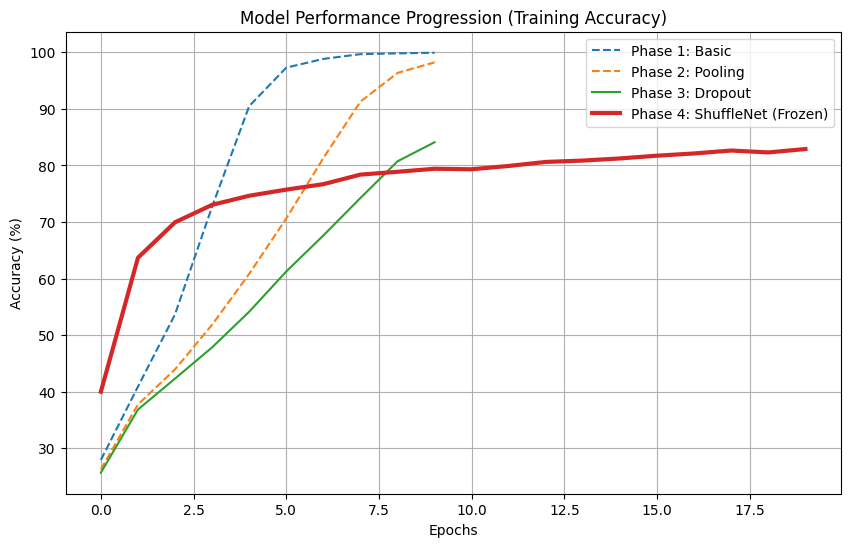

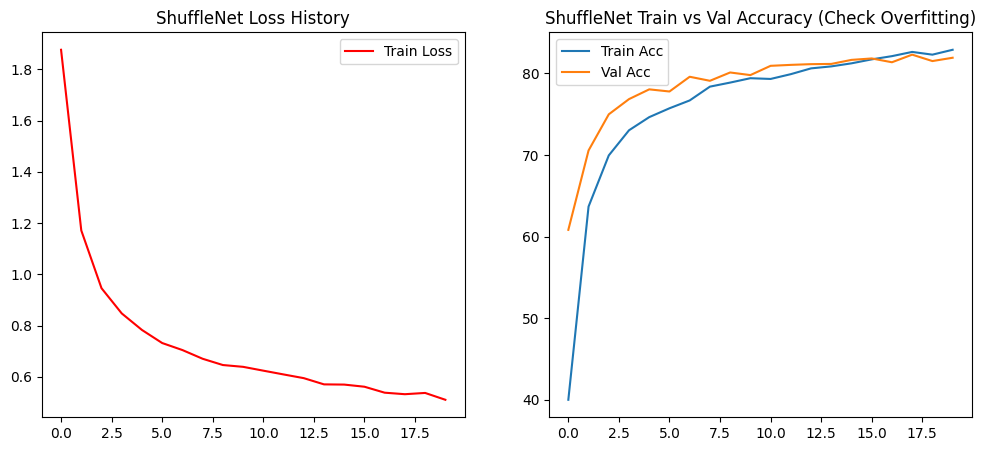

📊 evaluate (Test Set)...
🏆 Final Test Accuracy: 82.40%


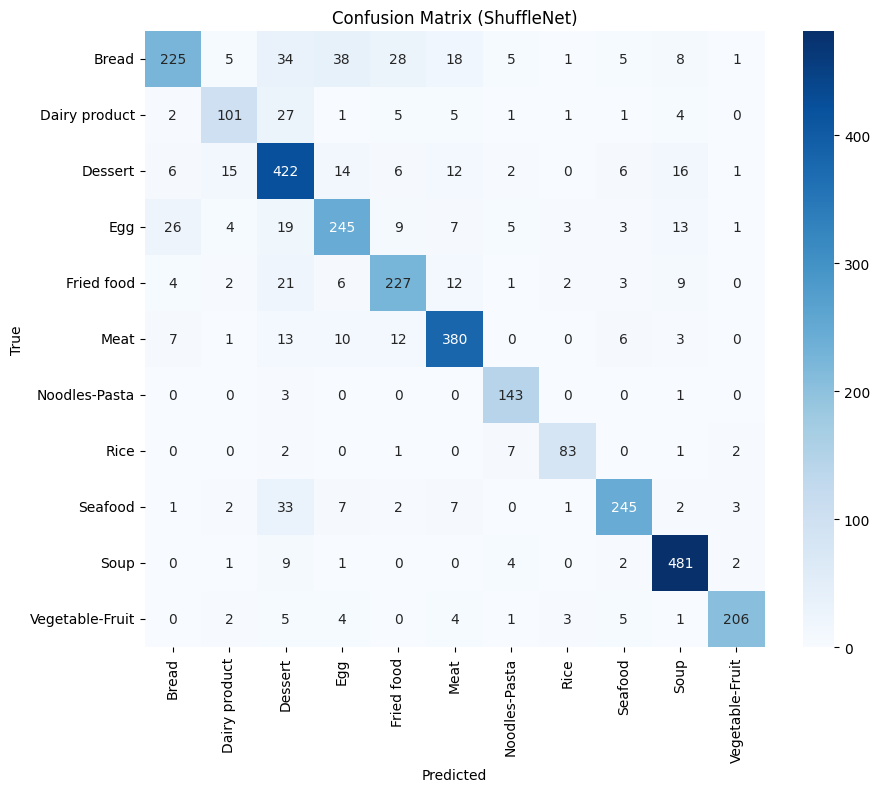

In [26]:
# summary and plotting
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
plt.plot(acc_p1, label='Phase 1: Basic', linestyle='--')
plt.plot(acc_p2, label='Phase 2: Pooling', linestyle='--')
plt.plot(acc_p3, label='Phase 3: Dropout')
plt.plot(shuffle_train_acc, label='Phase 4: ShuffleNet (Frozen)', linewidth=3)
plt.title('Model Performance Progression (Training Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# ShuffleNet Loss & Val Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(shuffle_loss, label='Train Loss', color='red')
plt.title('ShuffleNet Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(shuffle_train_acc, label='Train Acc')
plt.plot(shuffle_val_acc, label='Val Acc')
plt.title('ShuffleNet Train vs Val Accuracy (Check Overfitting)')
plt.legend()
plt.show()

print("📊 evaluate (Test Set)...")
model_shufflenet.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_shufflenet(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# calculate acc
test_correct = sum([1 for i in range(len(y_true)) if y_true[i] == y_pred[i]])
final_acc = 100 * test_correct / len(y_true)
print(f"🏆 Final Test Accuracy: {final_acc:.2f}%")

# confuse matrix
class_names = test_set.classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (ShuffleNet)')
plt.show()

In [27]:
# evaluate all model (phase1~4)
models_to_evaluate = {
    "Phase 1 (Basic)": model_phase1,
    "Phase 2 (Pooling)": model_phase2,
    "Phase 3 (Dropout)": model_phase3,
    "Phase 4 (ShuffleNet)": model_shufflenet
}

print("\n🔍 valuate all phase (Test Set)...")
print("-" * 50)

for name, model in models_to_evaluate.items():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"🔹 {name} Test Accuracy: {acc:.2f}%")

print("-" * 50)


🔍 valuate all phase (Test Set)...
--------------------------------------------------
🔹 Phase 1 (Basic) Test Accuracy: 42.25%
🔹 Phase 2 (Pooling) Test Accuracy: 43.65%
🔹 Phase 3 (Dropout) Test Accuracy: 50.52%
🔹 Phase 4 (ShuffleNet) Test Accuracy: 82.40%
--------------------------------------------------
